In [113]:
# --- Bibliotecas Padrão do Python ---
import warnings
import os

# --- Bibliotecas de Terceiros ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Componentes Específicos do sktime ---

# Modelos de Previsão (Forecasters)
from sktime.forecasting.arima import AutoARIMA
from sktime.forecasting.fbprophet import Prophet
from sktime.forecasting.naive import NaiveForecaster

# Ferramentas de Composição e Pipelines
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.transformations.series.boxcox import BoxCoxTransformer, LogTransformer

# Ferramentas de Avaliação e Validação
from sktime.forecasting.model_evaluation import evaluate
from sktime.forecasting.model_selection import (
    ExpandingWindowSplitter,
    SlidingWindowSplitter,
    temporal_train_test_split,
)
from sktime.performance_metrics.forecasting import (
    MeanAbsoluteError,
    MeanAbsolutePercentageError,
    MeanAbsoluteScaledError,
)

from sktime.performance_metrics.forecasting import (
    mean_absolute_error, 
    mean_absolute_scaled_error, 
    mean_absolute_percentage_error
)

from sktime.forecasting.model_selection import ForecastingGridSearchCV

# Funções de Plotagem
from sktime.utils.plotting import plot_series


# --- Configurações Iniciais ---
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

In [114]:
# --- 1. Carregar os Dados ---
print("--- Carregando dados... ---")

# O caminho para o teu ficheiro
caminho_do_arquivo = os.path.join('..', 'data', 'raw', 'dataset_serie_temporal.csv')
df_ts = pd.read_csv(caminho_do_arquivo)


# --- 2. Preparar a Série para SP ---
print("--- Preparando a série para SP... ---")

estado_exemplo = "SP"
df_estado = df_ts[df_ts["estado"] == estado_exemplo].copy()

# Cria a série inicial, já com um PeriodIndex
serie_estado = pd.Series(
    df_estado['y'].values, 
    index=pd.PeriodIndex(df_estado['periodo'], freq='M'),
    name='y'
).sort_index()

# Cria um índice completo para garantir que todos os meses estão presentes
idx_completo = pd.period_range(
    start=serie_estado.index.min(), 
    end=serie_estado.index.max(), 
    freq='M'
)

# Reindexa a série. Onde não houver dados, preenche com 0.
y_com_zeros = serie_estado.reindex(idx_completo, fill_value=0)


# --- 3. Imputação de Dados Ausentes ---
# A mesma lógica que tinhas: zeros viram NaN e depois são interpolados
y_com_nan = y_com_zeros.to_frame()
y_com_nan[y_com_nan['y'] == 0] = np.nan
y_imputado = y_com_nan.interpolate(method='linear')


# --- 4. Finalização ---
# Converte a coluna 'y' para inteiro
y_final = y_imputado.astype(int)

print("\n--- Dados Prontos ---")
print("Informações da série final:")
y_final.info()
print("\nÚltimos registos:")
print(y_final.tail())

--- Carregando dados... ---
--- Preparando a série para SP... ---

--- Dados Prontos ---
Informações da série final:
<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 134 entries, 2014-01 to 2025-02
Freq: M
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   y       134 non-null    int32
dtypes: int32(1)
memory usage: 1.6 KB

Últimos registos:
              y
2024-10   14301
2024-11   16752
2024-12   65541
2025-01  114331
2025-02  162274


In [115]:
# Lista para armazenar os resultados
results_list = []


# Horizontes de previsão a serem testados
horizonte = 12

# Modelos base a serem avaliados
modelos_base = {
    "NaiveSeasonal": NaiveForecaster(strategy="last", sp=12), # Modelo Ingênuo em que o valor previsto é igual ao valor do mesmo mês do ano anterior
    "ARIMA": AutoARIMA(sp=12, suppress_warnings=True, n_jobs=-1), # Modelo ARIMA automático com sazonalidade anual baseado em pmdarima
    "Prophet": Prophet(yearly_seasonality=True), # Modelo Prophet com sazonalidade anual baseado em Facebook Prophet
}

--- Iniciando Avaliação 1: Modelos Base com train_test_split e sem Transformação ---

--- Treinando e avaliando: NaiveSeasonal ---
MAE: 148022.25, MASE: 7.41, MAPE: 74.25%


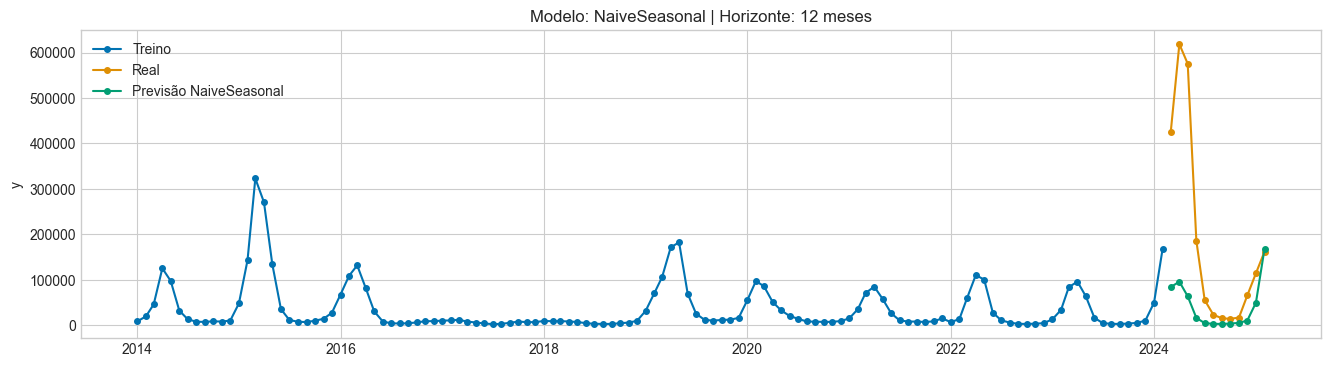


--- Treinando e avaliando: ARIMA ---


c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ens

MAE: 134621.22, MASE: 6.74, MAPE: 65.44%


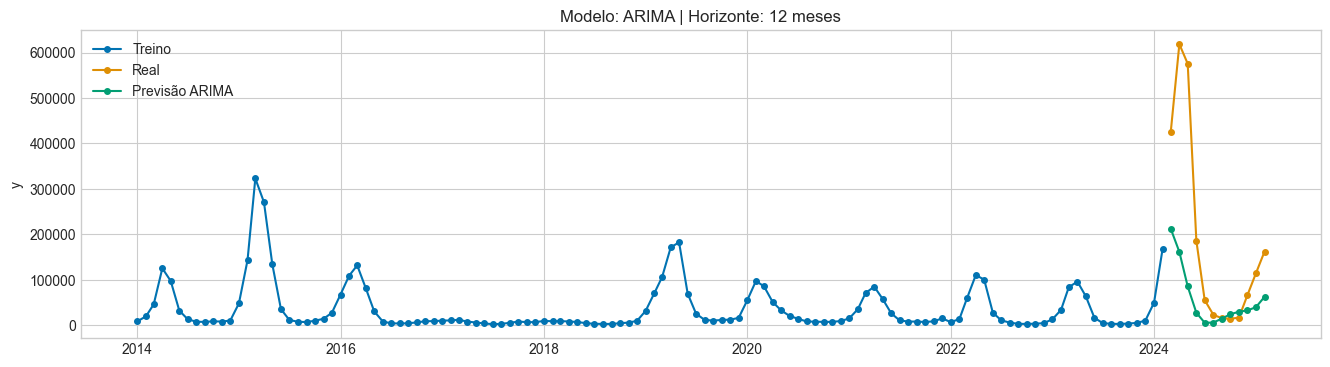


--- Treinando e avaliando: Prophet ---


18:34:05 - cmdstanpy - INFO - Chain [1] start processing
18:34:05 - cmdstanpy - INFO - Chain [1] done processing


MAE: 160029.11, MASE: 8.01, MAPE: 89.82%


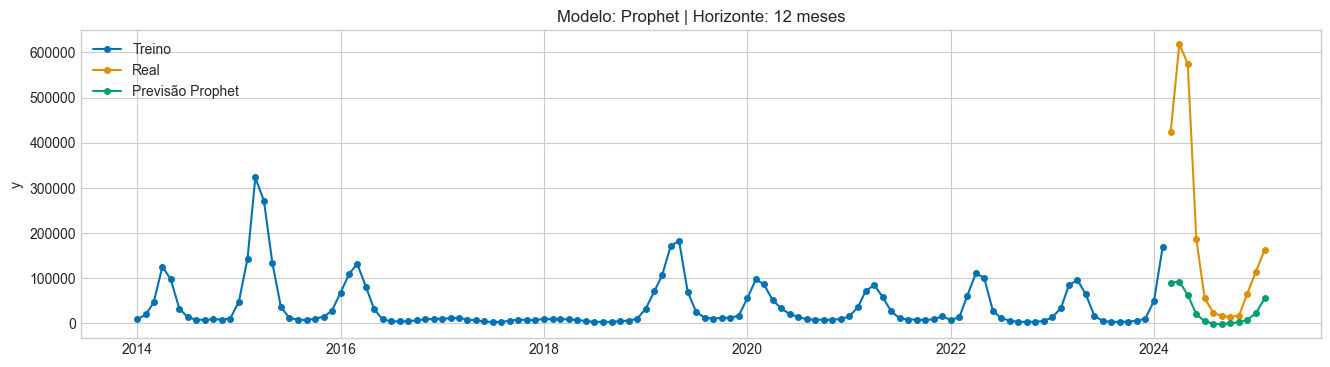


--- Tabela de Resultados Parcial ---


,modelo,parametros,transformacao,split_method,fh,mae,mase,mape
0,NaiveSeasonal,Base,Nenhuma,temporal_split (test_size=12),12,148022.250000,7.407400,0.742479
1,ARIMA,Base,Nenhuma,temporal_split (test_size=12),12,134621.215169,6.736779,0.654434
2,Prophet,Base,Nenhuma,temporal_split (test_size=12),12,160029.108052,8.008252,0.898207


In [116]:
print("--- Iniciando Avaliação 1: Modelos Base com train_test_split e sem Transformação ---")

# 1. Dividir os dados
y_train, y_test = temporal_train_test_split(y_final, test_size=horizonte)
fh = y_test.index

# Loop sobre cada modelo
for nome, modelo in modelos_base.items():
    print(f"\n--- Treinando e avaliando: {nome} ---")

    # 2. Treinar o modelo
    modelo.fit(y_train)

    # 3. Fazer a previsão
    y_pred = modelo.predict(fh)

    # 4. Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    mase = mean_absolute_scaled_error(y_test, y_pred, y_train=y_train)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # 5. Armazenar resultados
    results_list.append({
        "modelo": nome,
        "parametros": "Base",
        "transformacao": "Nenhuma",
        "split_method": f"temporal_split (test_size={horizonte})",
        "fh": horizonte,
        "mae": mae,
        "mase": mase,
        "mape": mape
    })

    print(f"MAE: {mae:.2f}, MASE: {mase:.2f}, MAPE: {mape:.2%}")

    # 6. Plotar gráfico
    plot_series(y_train, y_test, y_pred, labels=["Treino", "Real", f"Previsão {nome}"])
    plt.title(f"Modelo: {nome} | Horizonte: {horizonte} meses")
    plt.show()

# Criar o DataFrame final de resultados
results_df = pd.DataFrame(results_list)
print("\n--- Tabela de Resultados Parcial ---")
display(results_df)

O BoxCoxTransformer encontrou o lambda ideal: -0.2518
O lambda encontrado sugere que a transformação Box-Cox pode ser mais apropriada que a Logarítmica simples.


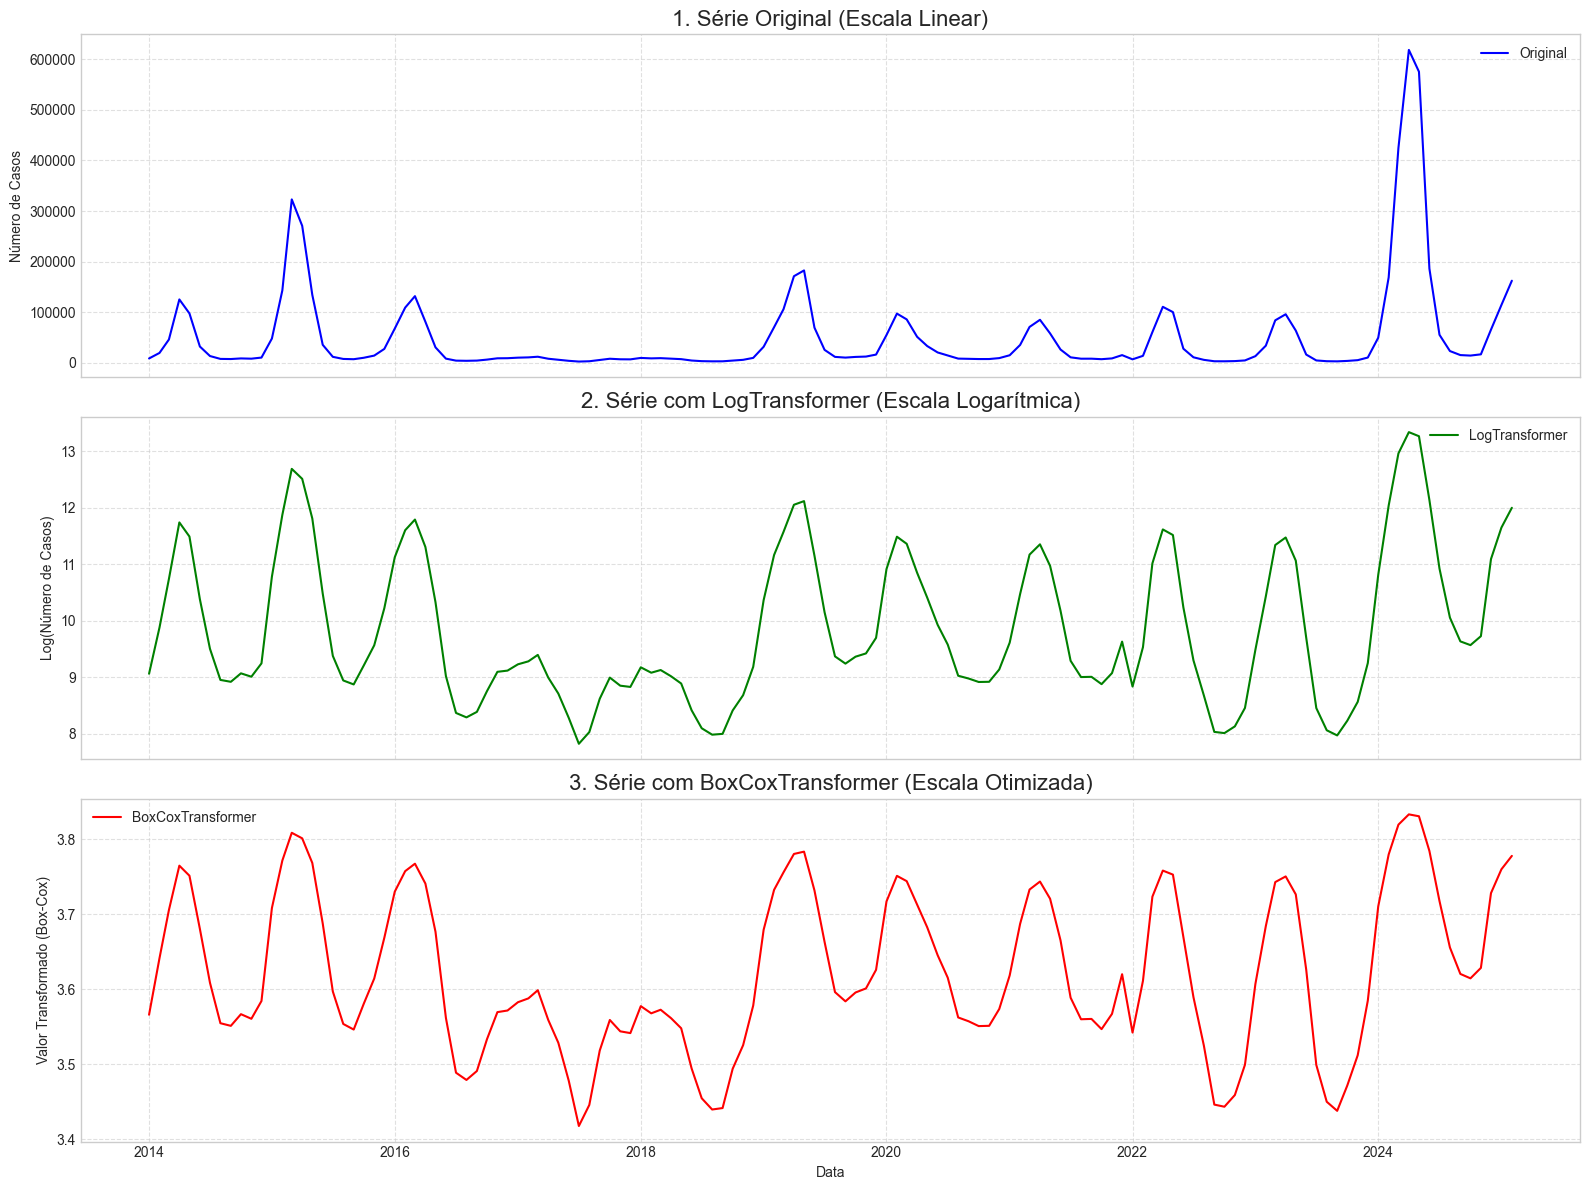

In [117]:
# Transformações dos dados de série epidemiológica por ter picos muitos altos
log_transformer = LogTransformer()
boxcox_transformer = BoxCoxTransformer() # Automaticamente encontra o melhor lambda para verificar se o log é adequado ou não

# Aplicar a transformação de Log
y_log = log_transformer.fit_transform(y_final)

# Aplicar a transformação de Box-Cox
y_boxcox = boxcox_transformer.fit_transform(y_final)

# O BoxCox armazena o lambda encontrado, útil para diagnóstico
lambda_encontrado = boxcox_transformer.lambda_
print(f"O BoxCoxTransformer encontrou o lambda ideal: {lambda_encontrado:.4f}")

# Adiciona a orientação de qual trasnformação utilizar baseada no valor do lambda
if abs(lambda_encontrado) < 0.1: # Um valor próximo de 0 (ex: < 0.1) sugere Log
    print("Como o lambda encontrado é próximo de zero, a transformação Logarítmica é uma boa alternativa.")
else:
    print("O lambda encontrado sugere que a transformação Box-Cox pode ser mais apropriada que a Logarítmica simples.")



# Criar os gráficos comparativos
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Gráfico 1: Série Original
ax1.plot(y_final.index.to_timestamp(), y_final['y'], label="Original", color='blue')
ax1.set_title("1. Série Original (Escala Linear)", fontsize=16)
ax1.set_ylabel("Número de Casos")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Série com LogTransformer
ax2.plot(y_log.index.to_timestamp(), y_log['y'], label="LogTransformer", color='green')
ax2.set_title("2. Série com LogTransformer (Escala Logarítmica)", fontsize=16)
ax2.set_ylabel("Log(Número de Casos)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Série com BoxCoxTransformer
ax3.plot(y_boxcox.index.to_timestamp(), y_boxcox['y'], label="BoxCoxTransformer", color='red')
ax3.set_title("3. Série com BoxCoxTransformer (Escala Otimizada)", fontsize=16)
ax3.set_ylabel("Valor Transformado (Box-Cox)")
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.6)

plt.xlabel("Data")
plt.tight_layout()
plt.show()

In [118]:
# Cada pipeline agora tem 3 passos: BoxCox -> Forecaster
pipelines_boxcox = {
    "NaiveSeasonal": TransformedTargetForecaster(steps=[
        ("boxcox", BoxCoxTransformer()),
        ("forecaster", NaiveForecaster(strategy="last", sp=12))
    ]),
    "ARIMA": TransformedTargetForecaster(steps=[
        ("boxcox", BoxCoxTransformer()),
        ("forecaster", AutoARIMA(sp=12, suppress_warnings=True, n_jobs=-1))
    ]),
    "Prophet": TransformedTargetForecaster(steps=[
        ("boxcox", BoxCoxTransformer()),
        ("forecaster", Prophet(yearly_seasonality=True))
    ]),
}

print(f"{len(pipelines_boxcox)} pipelines com transformação BoxCox foram criados com sucesso!")

3 pipelines com transformação BoxCox foram criados com sucesso!



--- Iniciando Avaliação 2: Pipelines com BoxCoxTransformer ---

--- Treinando e avaliando: NaiveSeasonal com BoxCox ---
MAE: 148022.25, MASE: 7.41, MAPE: 74.25%


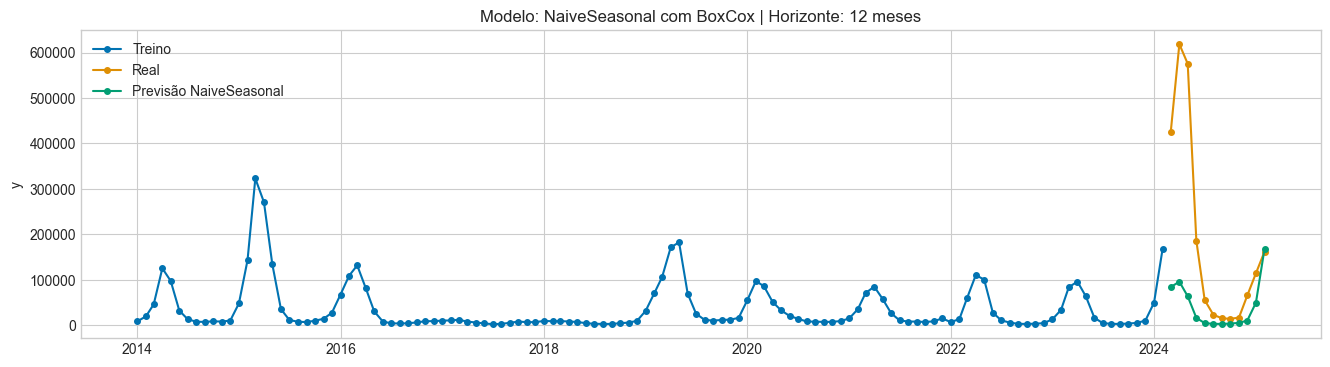


--- Treinando e avaliando: ARIMA com BoxCox ---


c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ens

MAE: 155288.63, MASE: 7.77, MAPE: 75.92%


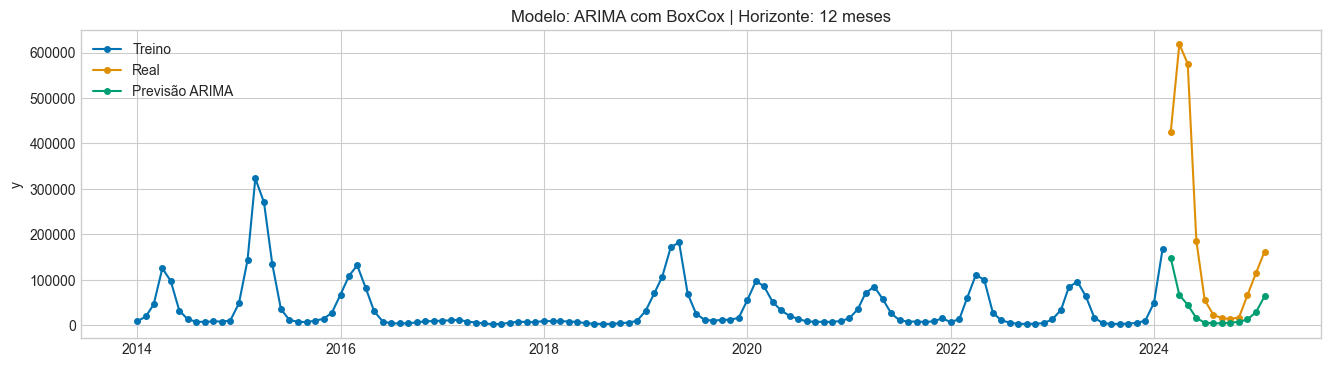

18:34:28 - cmdstanpy - INFO - Chain [1] start processing



--- Treinando e avaliando: Prophet com BoxCox ---


18:34:28 - cmdstanpy - INFO - Chain [1] done processing


MAE: 173072.82, MASE: 8.66, MAPE: 84.71%


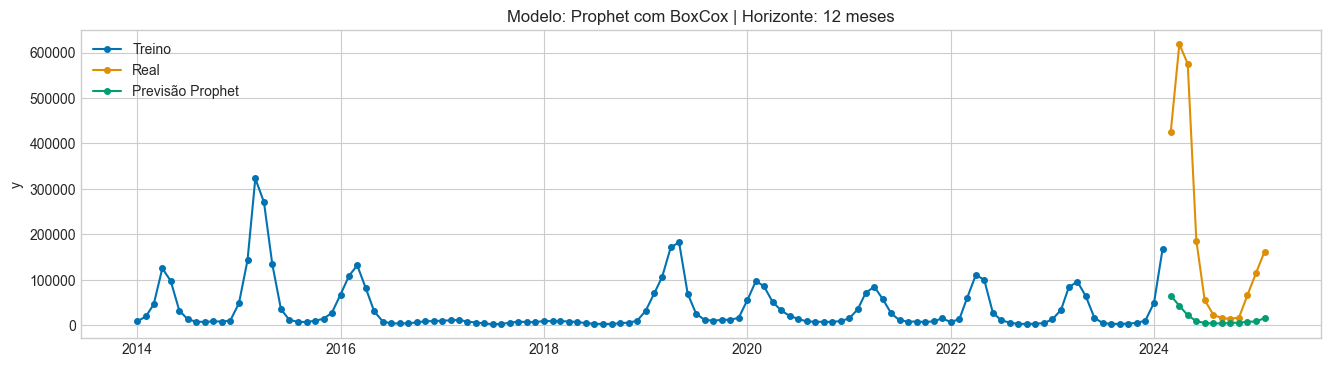


--- Tabela de Resultados Atualizada (Partes 1 e 2) ---


,modelo,parametros,transformacao,split_method,fh,mae,mase,mape
0,NaiveSeasonal,Base,Nenhuma,temporal_split (test_size=12),12,148022.250000,7.407400,0.742479
1,ARIMA,Base,Nenhuma,temporal_split (test_size=12),12,134621.215169,6.736779,0.654434
2,Prophet,Base,Nenhuma,temporal_split (test_size=12),12,160029.108052,8.008252,0.898207
3,NaiveSeasonal,base,BoxCox,temporal_split (test_size=12),12,148022.250000,7.407400,0.742479
4,ARIMA,base,BoxCox,temporal_split (test_size=12),12,155288.630775,7.771027,0.759212
5,Prophet,base,BoxCox,temporal_split (test_size=12),12,173072.818568,8.660992,0.847121


In [119]:
print("\n--- Iniciando Avaliação 2: Pipelines com BoxCoxTransformer ---")

# 1. Dividir os dados
y_train, y_test = temporal_train_test_split(y_final, test_size=horizonte)
fh = y_test.index

# Loop sobre cada pipeline
for nome, pipeline in pipelines_boxcox.items():
    print(f"\n--- Treinando e avaliando: {nome} com BoxCox ---")

    # 2. Treinar o pipeline
    pipeline.fit(y_train)

    # 3. Fazer a previsão (a reversão da transformação é automática)
    y_pred = pipeline.predict(fh)

    # 4. Calcular métricas
    mae = mean_absolute_error(y_test, y_pred)
    mase = mean_absolute_scaled_error(y_test, y_pred, y_train=y_train)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # 5. Armazenar resultados
    results_list.append({
        "modelo": nome,
        "parametros": "base",
        "transformacao": "BoxCox",
        "split_method": f"temporal_split (test_size={horizonte})",
        "fh": horizonte,
        "mae": mae,
        "mase": mase,
        "mape": mape
    })

    print(f"MAE: {mae:.2f}, MASE: {mase:.2f}, MAPE: {mape:.2%}")

    # 6. Plotar gráfico
    plot_series(y_train, y_test, y_pred, labels=["Treino", "Real", f"Previsão {nome}"])
    plt.title(f"Modelo: {nome} com BoxCox | Horizonte: {horizonte} meses")
    plt.show()

# Atualizar o DataFrame final de resultados com as novas execuções
results_df = pd.DataFrame(results_list)
print("\n--- Tabela de Resultados Atualizada (Partes 1 e 2) ---")
display(results_df)

In [121]:
fh_list = [i for i in range(1, horizonte + 1)]

# Defina as configurações de forma estruturada 
configuracoes_janelas = [
    # (Nome para o Dicionário,       Classe do Splitter,      Dicionário com os Parâmetros)
    ("Expansiva_Inicial_36_meses",    ExpandingWindowSplitter, {'initial_window': 36, 'step_length': 12, 'fh': fh_list}),
    ("Expansiva_Inicial_72_meses",    ExpandingWindowSplitter, {'initial_window': 72, 'step_length': 12, 'fh': fh_list}),
    ("Deslizante_Fixa_36_meses",      SlidingWindowSplitter,   {'window_length': 36, 'step_length': 12, 'fh': fh_list}),
    ("Deslizante_Fixa_60_meses",      SlidingWindowSplitter,   {'window_length': 60, 'step_length': 12, 'fh': fh_list}),
    ("Deslizante_Inicial_36_Fixa_36", SlidingWindowSplitter,   {'initial_window': 36, 'window_length': 36, 'step_length': 12, 'fh': fh_list})
]

# --- 3. Construa o dicionário de janelas de validação (janelas_cv) programaticamente ---
janelas_cv = {}
for nome, classe_splitter, params in configuracoes_janelas:
    # Cria a instância do splitter e adiciona ao dicionário
    janelas_cv[nome] = classe_splitter(**params)

# --- 4. Exibe o resultado para confirmação ---
print(f"\n{len(janelas_cv)} estratégias de validação foram criadas com sucesso:")
for nome, splitter_obj in janelas_cv.items():
    print(f" - {nome}: {splitter_obj}")

# --- 5. O seu dicionário de modelos (sem alterações) ---
modelos_para_testar = {
    "AutoARIMA": AutoARIMA(sp=12, suppress_warnings=True),
    "Prophet": Prophet(yearly_seasonality=True) 
}
print(f"\n{len(modelos_para_testar)} modelos foram definidos para teste.")


5 estratégias de validação foram criadas com sucesso:
 - Expansiva_Inicial_36_meses: ExpandingWindowSplitter(fh=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                        initial_window=36, step_length=12)
 - Expansiva_Inicial_72_meses: ExpandingWindowSplitter(fh=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                        initial_window=72, step_length=12)
 - Deslizante_Fixa_36_meses: SlidingWindowSplitter(fh=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                      step_length=12, window_length=36)
 - Deslizante_Fixa_60_meses: SlidingWindowSplitter(fh=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                      step_length=12, window_length=60)
 - Deslizante_Inicial_36_Fixa_36: SlidingWindowSplitter(fh=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                      initial_window=36, step_length=12, window_length=36)

2 modelos foram definidos para teste.


In [122]:
# Loop sobre cada modelo
for nome_modelo, modelo in modelos_para_testar.items():
    # Loop sobre cada estratégia de validação
    for nome_janela, cv_splitter in janelas_cv.items():
        print(f"\nA avaliar o modelo '{nome_modelo}' com a estratégia '{nome_janela}'...")
        
        try:
            # Executa a avaliação (backtesting)
            df_results = evaluate(
                forecaster=modelo,
                y=y_final['y'],
                cv=cv_splitter,
                scoring=[MeanAbsoluteScaledError(), MeanAbsoluteError(), MeanAbsolutePercentageError()],
                return_data=False # Retorna apenas as métricas, não as previsões
            )

            # Calcula a média das métricas de todos os folds 
            mean_mae = df_results["test_MeanAbsoluteError"].mean()
            mean_mase = df_results["test_MeanAbsoluteScaledError"].mean()
            mean_mape = df_results["test_MeanAbsolutePercentageError"].mean()

            # Armazena os resultados
            results_list.append({
                "modelo": nome_modelo,
                "parametros": "Base",
                "transformacao": "Nenhuma",
                "split_method": f"{nome_janela} (mean)",
                "fh": horizonte,
                "mae": mean_mae,
                "mase": mean_mase,
                "mape": mean_mape
            })

            print(f"  Resultado -> MAE: {mean_mae:.2f}, MASE: {mean_mase:.2f}, MAPE: {mean_mape:.2%}")

        except Exception as e:
            print(f"  !!! Erro ao avaliar o modelo {nome_modelo} com {nome_janela}: {e}")

# --- 4. Tabela de Resultados Final ---
if results_list:
    df_resultados_finais = pd.DataFrame(results_list)
    
    print("\n\n--- Ranking Final de Performance (ordenado por MAPE) ---")
    print(df_resultados_finais.sort_values(by='mape'))
else:
    print("\nNenhuma avaliação foi concluída com sucesso.")


A avaliar o modelo 'AutoARIMA' com a estratégia 'Expansiva_Inicial_36_meses'...


c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ens

  Resultado -> MAE: 47671.36, MASE: 2.29, MAPE: 314.39%

A avaliar o modelo 'AutoARIMA' com a estratégia 'Expansiva_Inicial_72_meses'...


c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\55219\Desktop\Lucas\TI\Arquivos\Projetos_aprendizado\TechChallenge_Fase3_Dengue\venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ens

  Resultado -> MAE: 51293.01, MASE: 2.65, MAPE: 185.77%

A avaliar o modelo 'AutoARIMA' com a estratégia 'Deslizante_Fixa_36_meses'...


...

  Resultado -> MAE: 42623.40, MASE: 2.21, MAPE: 101.93%

A avaliar o modelo 'Prophet' com a estratégia 'Deslizante_Fixa_36_meses'...


18:38:38 - cmdstanpy - INFO - Chain [1] done processing
18:38:38 - cmdstanpy - INFO - Chain [1] start processing
18:38:39 - cmdstanpy - INFO - Chain [1] done processing
18:38:39 - cmdstanpy - INFO - Chain [1] start processing
18:38:39 - cmdstanpy - INFO - Chain [1] done processing
18:38:39 - cmdstanpy - INFO - Chain [1] start processing
18:38:39 - cmdstanpy - INFO - Chain [1] done processing
18:38:40 - cmdstanpy - INFO - Chain [1] start processing
18:38:40 - cmdstanpy - INFO - Chain [1] done processing
18:38:40 - cmdstanpy - INFO - Chain [1] start processing
18:38:40 - cmdstanpy - INFO - Chain [1] done processing
18:38:41 - cmdstanpy - INFO - Chain [1] start processing
18:38:41 - cmdstanpy - INFO - Chain [1] done processing
18:38:41 - cmdstanpy - INFO - Chain [1] start processing
18:38:41 - cmdstanpy - INFO - Chain [1] done processing
18:38:41 - cmdstanpy - INFO - Chain [1] start processing


  Resultado -> MAE: 59580.38, MASE: 4.10, MAPE: 442.54%

A avaliar o modelo 'Prophet' com a estratégia 'Deslizante_Fixa_60_meses'...


18:38:42 - cmdstanpy - INFO - Chain [1] done processing
18:38:42 - cmdstanpy - INFO - Chain [1] start processing
18:38:42 - cmdstanpy - INFO - Chain [1] done processing
18:38:42 - cmdstanpy - INFO - Chain [1] start processing
18:38:42 - cmdstanpy - INFO - Chain [1] done processing
18:38:42 - cmdstanpy - INFO - Chain [1] start processing
18:38:43 - cmdstanpy - INFO - Chain [1] done processing
18:38:43 - cmdstanpy - INFO - Chain [1] start processing
18:38:43 - cmdstanpy - INFO - Chain [1] done processing
18:38:43 - cmdstanpy - INFO - Chain [1] start processing
18:38:43 - cmdstanpy - INFO - Chain [1] done processing


  Resultado -> MAE: 51583.07, MASE: 2.92, MAPE: 182.35%

A avaliar o modelo 'Prophet' com a estratégia 'Deslizante_Inicial_36_Fixa_36'...
  !!! Erro ao avaliar o modelo Prophet com Deslizante_Inicial_36_Fixa_36: `initial_window` must greater than `window_length`


--- Ranking Final de Performance (ordenado por MAPE) ---
           modelo parametros transformacao                       split_method  \
1           ARIMA       Base       Nenhuma      temporal_split (test_size=12)   
0   NaiveSeasonal       Base       Nenhuma      temporal_split (test_size=12)   
3   NaiveSeasonal       base        BoxCox      temporal_split (test_size=12)   
4           ARIMA       base        BoxCox      temporal_split (test_size=12)   
5         Prophet       base        BoxCox      temporal_split (test_size=12)   
2         Prophet       Base       Nenhuma      temporal_split (test_size=12)   
11        Prophet       Base       Nenhuma  Expansiva_Inicial_72_meses (mean)   
9       AutoARIMA       Base  

In [123]:
# Atualizar o DataFrame final de resultados com as novas execuções
results_df = pd.DataFrame(results_list)
print("\n--- Tabela de Resultados Atualizada (Partes 1, 2 e 3) ---")
display(results_df)


--- Tabela de Resultados Atualizada (Partes 1, 2 e 3) ---


,modelo,parametros,transformacao,split_method,fh,mae,mase,mape
0,NaiveSeasonal,Base,Nenhuma,temporal_split (test_size=12),12,148022.250000,7.407400,0.742479
1,ARIMA,Base,Nenhuma,temporal_split (test_size=12),12,134621.215169,6.736779,0.654434
2,Prophet,Base,Nenhuma,temporal_split (test_size=12),12,160029.108052,8.008252,0.898207
3,NaiveSeasonal,base,BoxCox,temporal_split (test_size=12),12,148022.250000,7.407400,0.742479
4,ARIMA,base,BoxCox,temporal_split (test_size=12),12,155288.630775,7.771027,0.759212
5,Prophet,base,BoxCox,temporal_split (test_size=12),12,173072.818568,8.660992,0.847121
6,AutoARIMA,Base,Nenhuma,Expansiva_Inicial_36_meses (mean),12,47671.358081,2.294339,3.143862
7,AutoARIMA,Base,Nenhuma,Expansiva_Inicial_72_meses (mean),12,51293.011024,2.646920,1.857729
8,AutoARIMA,Base,Nenhuma,Deslizante_Fixa_36_meses (mean),12,44956.160787,3.185277,2.447360
9,AutoARIMA,Base,Nenhuma,Deslizante_Fixa_60_meses (mean),12,53105.100562,3.072616,1.692078


In [124]:
y_final[y_final <= 0] = 1
y_treino, y_teste = temporal_train_test_split(y_final, test_size=horizonte)

In [127]:
# Atuar exclusivamente no Prophet uma vez que o AutoARIMA já faz a busca automática de parâmetros
# Melhor Estratégia atual
cv_splitter = ExpandingWindowSplitter(initial_window=72, step_length=12, fh=fh_list)
splitter_name = "Expansiva_Inicial_72_meses (grid)"

param_grid = {
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_prior_scale': [0.01, 0.05, 0.5],
    'seasonality_prior_scale': [1.0, 10.0],
    'yearly_seasonality': [True]
}

gscv_prophet = ForecastingGridSearchCV(
    Prophet(growth='linear'),
    cv=cv_splitter,
    param_grid=param_grid,
    scoring=MeanAbsoluteScaledError(),
)

In [130]:
try:
    print(f"\n--- A otimizar o modelo 'Prophet' com ForecastingGridSearchCV... ---")

    gscv_prophet.fit(y_final['y'])
    print(f"\nMelhores parâmetros encontrados: {gscv_prophet.best_params_}")
    print(f"Melhor score MASE: {gscv_prophet.best_score_:.4f}")

    # Pega o melhor modelo encontrado
    melhor_modelo = gscv_prophet.best_forecaster_
    
    # Executa a avaliação no melhor modelo para obter TODAS as métricas
    df_results = evaluate(
        forecaster=melhor_modelo,
        y=y_final['y'],
        cv=cv_splitter,
        scoring=[MeanAbsoluteScaledError(), MeanAbsoluteError(), MeanAbsolutePercentageError()],
        return_data=False
    )

    # Calcula a média das métricas de todos os folds
    mean_mae = df_results["test_MeanAbsoluteError"].mean()
    mean_mase = df_results["test_MeanAbsoluteScaledError"].mean()
    mean_mape = df_results["test_MeanAbsolutePercentageError"].mean()
    
    print(f"  Resultado Médio -> MAE: {mean_mae:.2f}, MASE: {mean_mase:.2f}, MAPE: {mean_mape:.2%}")

    # Cria a nova linha com os resultados
    results_list.append ({
        "modelo": "Prophet-Otimizado",
        "parametros": str(gscv_prophet.best_params_),
        "transformacao": "Nenhuma",
        "split_method": splitter_name,
        "fh": horizonte,
        "mae": mean_mae,
        "mase": mean_mase,
        "mape": mean_mape
    })

except Exception as e:
        print(f"  !!! Erro ao otimizar o modelo: {e}")

# Atualizar o DataFrame final de resultados com as novas execuções
results_df = pd.DataFrame(results_list)
print("\n--- Tabela de Resultados Atualizada (Partes 1, 2, 3 e 4) ---")
display(results_df)


--- A otimizar o modelo 'Prophet' com ForecastingGridSearchCV... ---


18:41:56 - cmdstanpy - INFO - Chain [1] start processing
18:41:56 - cmdstanpy - INFO - Chain [1] done processing
18:41:56 - cmdstanpy - INFO - Chain [1] start processing
18:41:56 - cmdstanpy - INFO - Chain [1] done processing



Melhores parâmetros encontrados: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10.0, 'yearly_seasonality': True}
Melhor score MASE: 2.0085


18:41:56 - cmdstanpy - INFO - Chain [1] start processing
18:41:57 - cmdstanpy - INFO - Chain [1] done processing
18:41:57 - cmdstanpy - INFO - Chain [1] start processing
18:41:57 - cmdstanpy - INFO - Chain [1] done processing
18:41:58 - cmdstanpy - INFO - Chain [1] start processing
18:41:58 - cmdstanpy - INFO - Chain [1] done processing
18:41:58 - cmdstanpy - INFO - Chain [1] start processing
18:41:58 - cmdstanpy - INFO - Chain [1] done processing
18:41:59 - cmdstanpy - INFO - Chain [1] start processing
18:41:59 - cmdstanpy - INFO - Chain [1] done processing


  Resultado Médio -> MAE: 38598.21, MASE: 2.01, MAPE: 50.93%

--- Tabela de Resultados Atualizada (Partes 1, 2, 3 e 4) ---


,modelo,parametros,transformacao,split_method,fh,mae,mase,mape
0,NaiveSeasonal,Base,Nenhuma,temporal_split (test_size=12),12,148022.250000,7.407400,0.742479
1,ARIMA,Base,Nenhuma,temporal_split (test_size=12),12,134621.215169,6.736779,0.654434
2,Prophet,Base,Nenhuma,temporal_split (test_size=12),12,160029.108052,8.008252,0.898207
3,NaiveSeasonal,base,BoxCox,temporal_split (test_size=12),12,148022.250000,7.407400,0.742479
4,ARIMA,base,BoxCox,temporal_split (test_size=12),12,155288.630775,7.771027,0.759212
5,Prophet,base,BoxCox,temporal_split (test_size=12),12,173072.818568,8.660992,0.847121
6,AutoARIMA,Base,Nenhuma,Expansiva_Inicial_36_meses (mean),12,47671.358081,2.294339,3.143862
7,AutoARIMA,Base,Nenhuma,Expansiva_Inicial_72_meses (mean),12,51293.011024,2.646920,1.857729
8,AutoARIMA,Base,Nenhuma,Deslizante_Fixa_36_meses (mean),12,44956.160787,3.185277,2.447360
9,AutoARIMA,Base,Nenhuma,Deslizante_Fixa_60_meses (mean),12,53105.100562,3.072616,1.692078


In [133]:
import pickle

# Defina aqui a pasta onde quer salvar os modelos
caminho_modelos = os.path.join('..', 'models', 'modelos_series_temporais')
os.makedirs(caminho_modelos, exist_ok=True)

# --- 1. Carregar e Preparar os Dados ---
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3584 entries, 0 to 3583
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   periodo  3584 non-null   object
 1   y        3584 non-null   int64 
 2   estado   3584 non-null   object
dtypes: int64(1), object(2)
memory usage: 84.1+ KB


In [139]:
# Dicionário vazio para guardar as séries temporais de cada estado
dfs_por_estado = {}

# Obtém a lista de estados únicos
lista_de_resultados = []
estados_unicos = df_ts['estado'].unique()
print(f"\nEncontrados os seguintes estados: {list(estados_unicos)}")


Encontrados os seguintes estados: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


In [144]:
# Itera sobre cada estado para criar um DataFrame separado
for estado in estados_unicos:
    # Filtra o DataFrame original para o estado atual
    df_estado = df_ts[df_ts['estado'] == estado].copy()
    
    # Cria a série temporal, definindo o 'y' como os dados
    # e usando a coluna 'periodo' para criar um PeriodIndex com frequência Mensal ('M')
    serie_temporal_estado = pd.Series(
        df_estado['y'].values, 
        index=pd.PeriodIndex(df_estado['periodo'], freq='M'),
        name='y'
    ).sort_index()
    
    # Guarda a série temporal no dicionário, usando a sigla do estado como chave
    dfs_por_estado[estado] = serie_temporal_estado.sort_index()

    idx_completo = pd.period_range(start=serie_temporal_estado.index.min(), end=serie_temporal_estado.index.max(), freq='M')
    y_com_zeros = serie_temporal_estado.reindex(idx_completo, fill_value=0)
    
    y_com_nan = y_com_zeros.to_frame()
    y_com_nan[y_com_nan['y'] == 0] = np.nan
    y_imputado = y_com_nan.interpolate(method='linear')
    
    y_final = y_imputado.astype(int)['y'] # Pega a Série 'y' do DataFrame

    dfs_por_estado[estado] = y_final

    #   --- b) Treino e Avaliação com sktime ---
    horizonte = 12
    fh_list = [i for i in range(1, horizonte + 1)]
    cv_splitter = ExpandingWindowSplitter(initial_window=72, step_length=12, fh=fh_list)

    modelo_prophet = Prophet(
        changepoint_prior_scale=0.05, 
        seasonality_mode='multiplicative', 
        seasonality_prior_scale=10.0, 
        yearly_seasonality=True
    )
    
    try:
        print(f"--- {estado}: A avaliar o modelo Prophet... ---")
        df_results = evaluate(
            forecaster=modelo_prophet,
            y=y_final,
            cv=cv_splitter,
            scoring=MeanAbsolutePercentageError(symmetric=False)
        )
        mape_medio = df_results["test_MeanAbsolutePercentageError"].mean()
        
        # Guarda o resultado
        lista_de_resultados.append({'UF': estado, 'MAPE_Medio': mape_medio})
        print(f"  - Avaliação para {estado} concluída. MAPE Médio: {mape_medio:.2%}")

        # --- c) Treino Final e Salvamento do Modelo ---
        print(f"--- {estado}: A treinar o modelo final e a salvar... ---")
        modelo_final = Prophet(
            changepoint_prior_scale=0.05, 
            seasonality_mode='multiplicative', 
            seasonality_prior_scale=10.0, 
            yearly_seasonality=True
        )
        modelo_final.fit(y_final) # Treina com todos os dados da UF
        
        # Salva o modelo treinado
        caminho_ficheiro_modelo = os.path.join(caminho_modelos, f'modelo_prophet_{estado}.pkl')
        with open(caminho_ficheiro_modelo, 'wb') as f:
            pickle.dump(modelo_final, f)
        print(f"  - Modelo para {estado} salvo em: {caminho_ficheiro_modelo}")

    except Exception as e:
        print(f"  !!! Erro ao processar a UF {estado}: {e}")
        lista_de_resultados.append({'UF': estado, 'MAPE_Medio': np.nan})

# --- 3. Tabela de Resultados Final ---
if lista_de_resultados:
    df_resultados_finais = pd.DataFrame(lista_de_resultados)
    print("\n\n--- Tabela Final de Performance (MAPE Médio por Estado) ---")
    display(df_resultados_finais.sort_values(by='MAPE_Medio').set_index('UF'))
else:
    print("\nNenhuma avaliação foi concluída com sucesso.")

19:25:24 - cmdstanpy - INFO - Chain [1] start processing


--- AC: A avaliar o modelo Prophet... ---


19:25:24 - cmdstanpy - INFO - Chain [1] done processing
19:25:25 - cmdstanpy - INFO - Chain [1] start processing
19:25:25 - cmdstanpy - INFO - Chain [1] done processing
19:25:25 - cmdstanpy - INFO - Chain [1] start processing
19:25:26 - cmdstanpy - INFO - Chain [1] done processing
19:25:26 - cmdstanpy - INFO - Chain [1] start processing
19:25:26 - cmdstanpy - INFO - Chain [1] done processing
19:25:26 - cmdstanpy - INFO - Chain [1] start processing
19:25:26 - cmdstanpy - INFO - Chain [1] done processing
19:25:26 - cmdstanpy - INFO - Chain [1] start processing
19:25:26 - cmdstanpy - INFO - Chain [1] done processing


  - Avaliação para AC concluída. MAPE Médio: 325.62%
--- AC: A treinar o modelo final e a salvar... ---
  - Modelo para AC salvo em: ..\models\modelos_series_temporais\modelo_prophet_AC.pkl
--- AL: A avaliar o modelo Prophet... ---


19:25:26 - cmdstanpy - INFO - Chain [1] start processing
19:25:27 - cmdstanpy - INFO - Chain [1] done processing
19:25:27 - cmdstanpy - INFO - Chain [1] start processing
19:25:27 - cmdstanpy - INFO - Chain [1] done processing
19:25:27 - cmdstanpy - INFO - Chain [1] start processing
19:25:27 - cmdstanpy - INFO - Chain [1] done processing
19:25:28 - cmdstanpy - INFO - Chain [1] start processing
19:25:28 - cmdstanpy - INFO - Chain [1] done processing
19:25:28 - cmdstanpy - INFO - Chain [1] start processing
19:25:28 - cmdstanpy - INFO - Chain [1] done processing
19:25:28 - cmdstanpy - INFO - Chain [1] start processing
19:25:28 - cmdstanpy - INFO - Chain [1] done processing


...

19:26:18 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:19 - cmdstanpy - INFO - Chain [1] done processing
19:26:19 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing
19:26:20 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing
19:26:20 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing
19:26:20 - cmdstanpy - INFO - Chain [1] start processing
19:26:20 - cmdstanpy - INFO - Chain [1] done processing


  - Avaliação para SP concluída. MAPE Médio: 50.93%
--- SP: A treinar o modelo final e a salvar... ---
  - Modelo para SP salvo em: ..\models\modelos_series_temporais\modelo_prophet_SP.pkl
--- TO: A avaliar o modelo Prophet... ---


19:26:20 - cmdstanpy - INFO - Chain [1] start processing
19:26:21 - cmdstanpy - INFO - Chain [1] done processing
19:26:21 - cmdstanpy - INFO - Chain [1] start processing
19:26:21 - cmdstanpy - INFO - Chain [1] done processing
19:26:21 - cmdstanpy - INFO - Chain [1] start processing
19:26:22 - cmdstanpy - INFO - Chain [1] done processing
19:26:22 - cmdstanpy - INFO - Chain [1] start processing
19:26:22 - cmdstanpy - INFO - Chain [1] done processing
19:26:22 - cmdstanpy - INFO - Chain [1] start processing
19:26:22 - cmdstanpy - INFO - Chain [1] done processing
19:26:22 - cmdstanpy - INFO - Chain [1] start processing
19:26:22 - cmdstanpy - INFO - Chain [1] done processing


  - Avaliação para TO concluída. MAPE Médio: 381.40%
--- TO: A treinar o modelo final e a salvar... ---
  - Modelo para TO salvo em: ..\models\modelos_series_temporais\modelo_prophet_TO.pkl


--- Tabela Final de Performance (MAPE Médio por Estado) ---


,MAPE_Medio
UF,
MT,0.447178
MT,0.447178
PA,0.458933
PA,0.458933
SP,0.509318
...,...
TO,3.814049
RR,15.797869
RR,15.797869


<Figure size 1000x500 with 0 Axes>

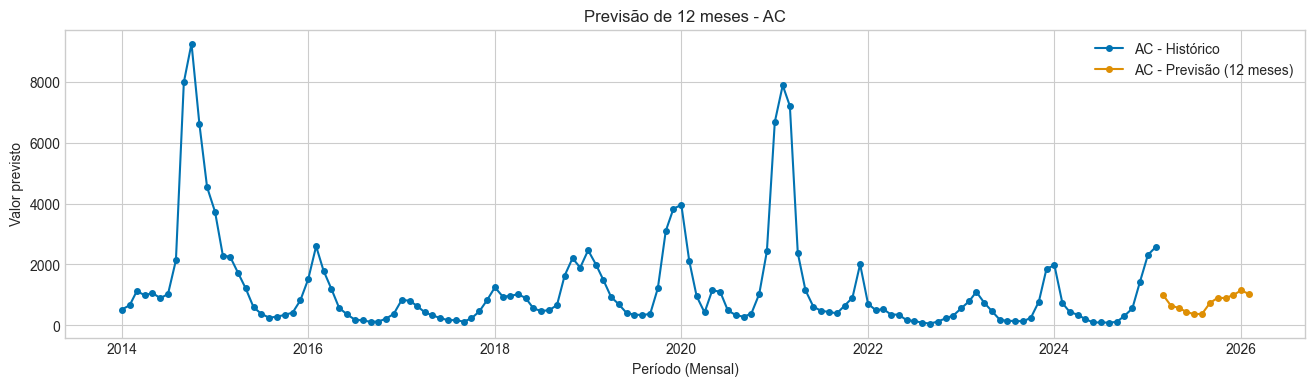

✅ Previsão e gráfico gerados para AC


<Figure size 1000x500 with 0 Axes>

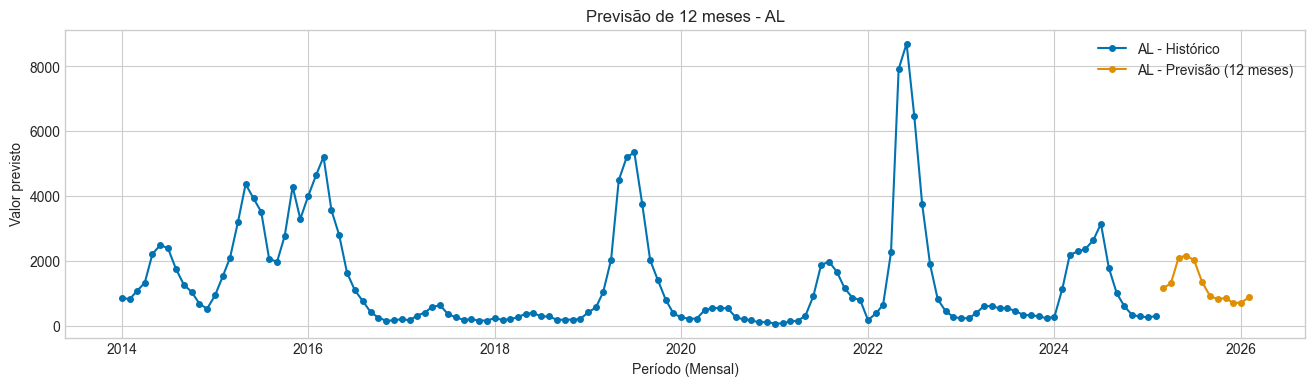

✅ Previsão e gráfico gerados para AL


<Figure size 1000x500 with 0 Axes>

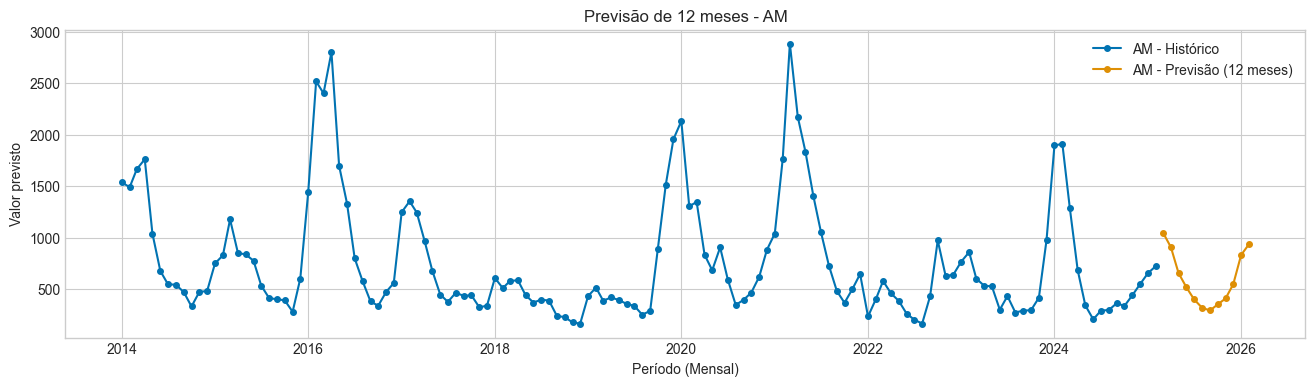

✅ Previsão e gráfico gerados para AM


<Figure size 1000x500 with 0 Axes>

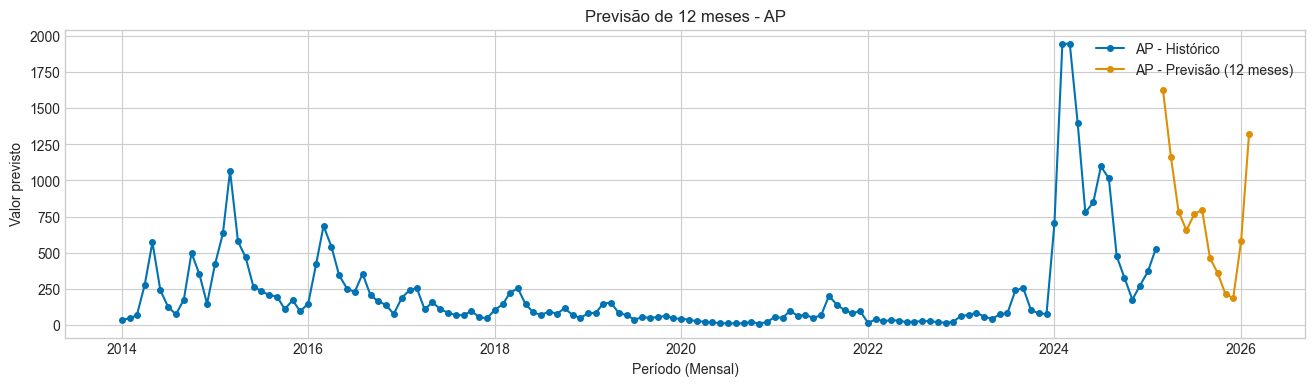

✅ Previsão e gráfico gerados para AP


<Figure size 1000x500 with 0 Axes>

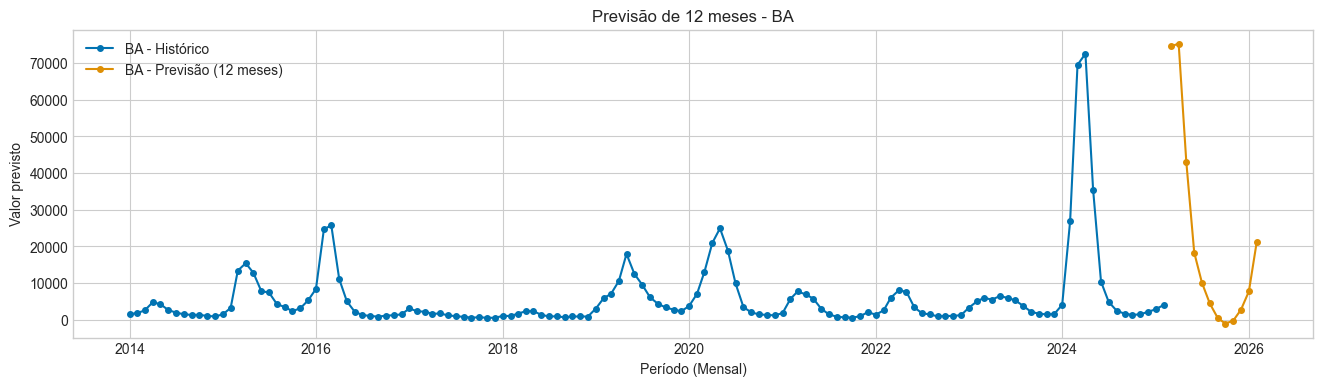

✅ Previsão e gráfico gerados para BA


<Figure size 1000x500 with 0 Axes>

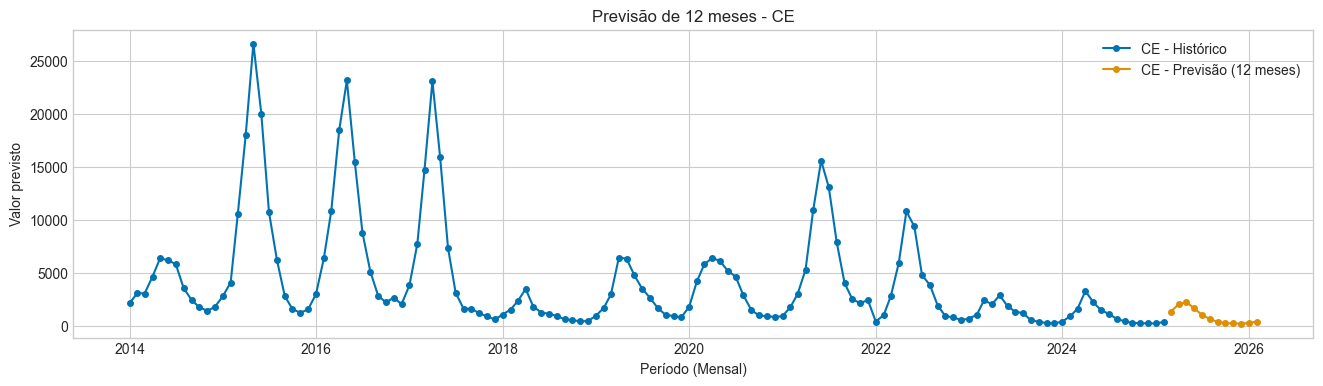

✅ Previsão e gráfico gerados para CE


<Figure size 1000x500 with 0 Axes>

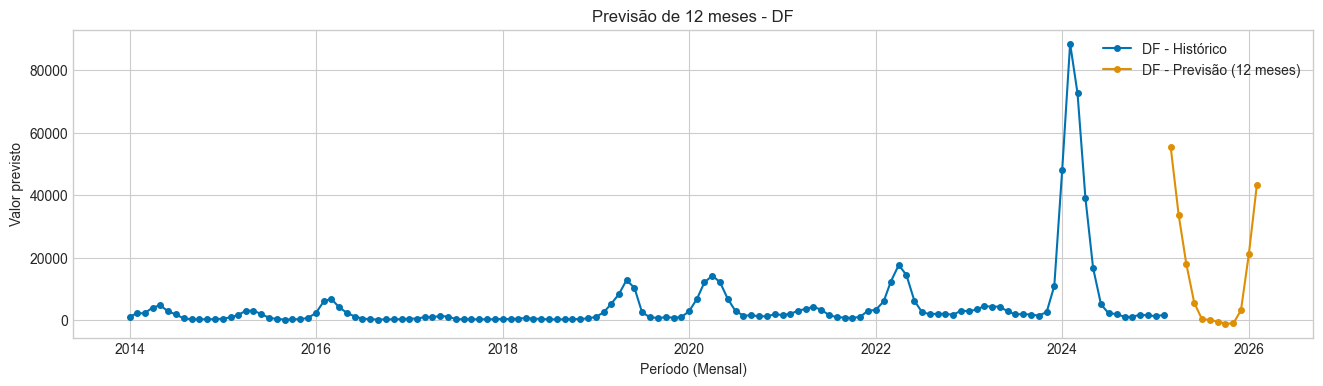

✅ Previsão e gráfico gerados para DF


<Figure size 1000x500 with 0 Axes>

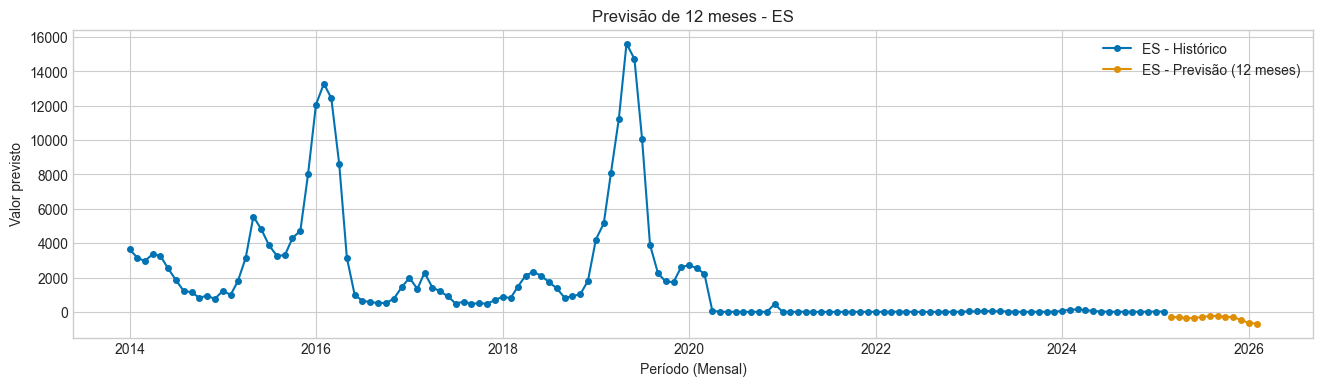

✅ Previsão e gráfico gerados para ES


<Figure size 1000x500 with 0 Axes>

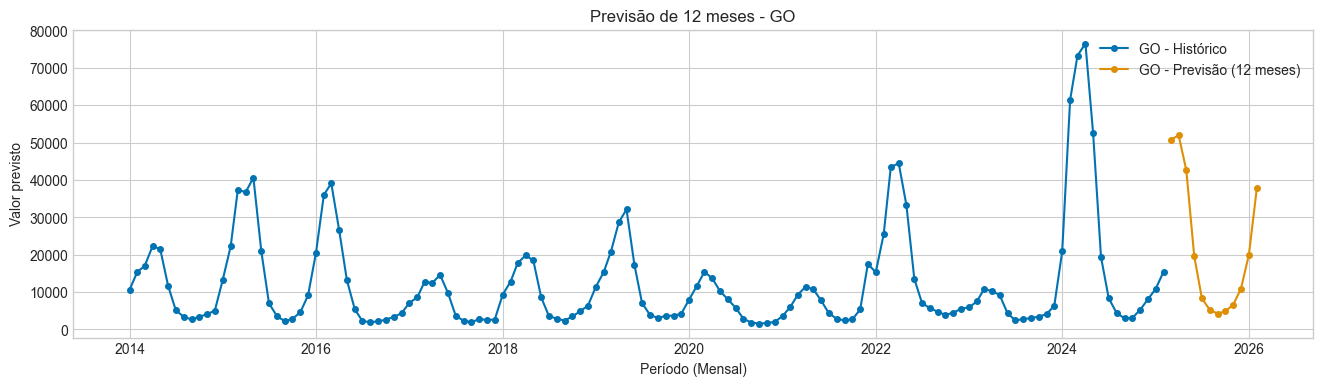

✅ Previsão e gráfico gerados para GO


<Figure size 1000x500 with 0 Axes>

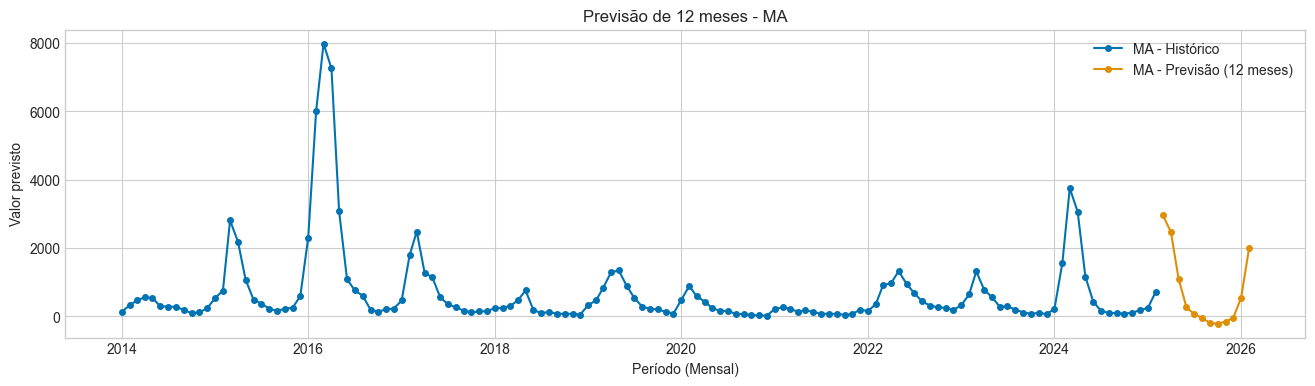

✅ Previsão e gráfico gerados para MA


<Figure size 1000x500 with 0 Axes>

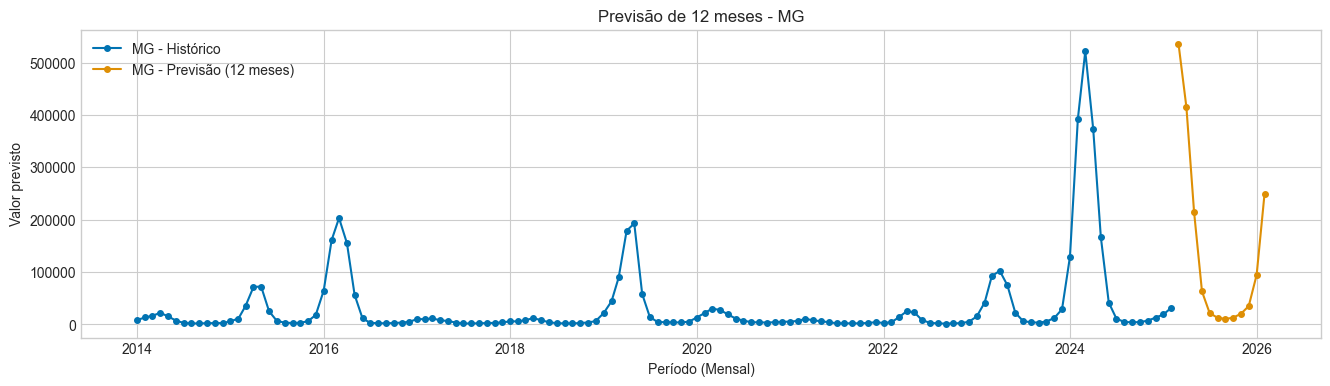

✅ Previsão e gráfico gerados para MG


<Figure size 1000x500 with 0 Axes>

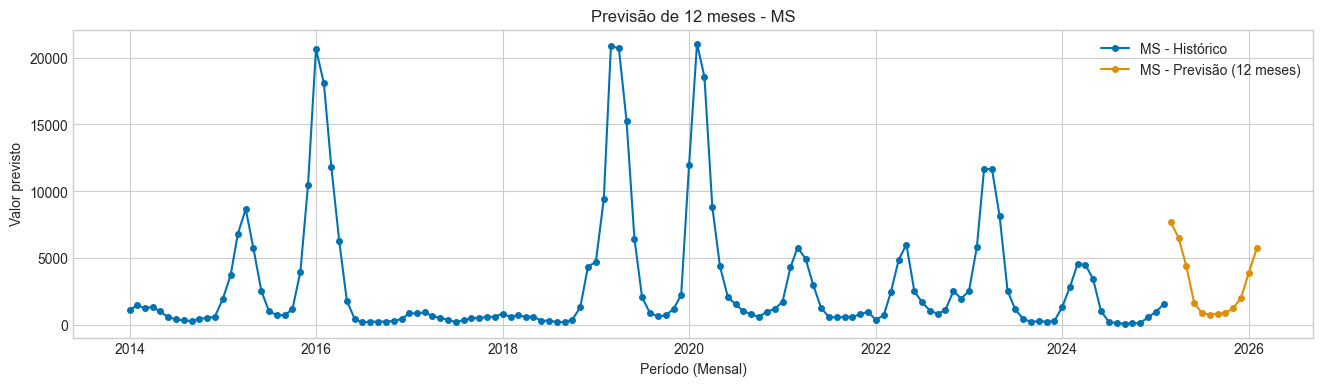

✅ Previsão e gráfico gerados para MS


<Figure size 1000x500 with 0 Axes>

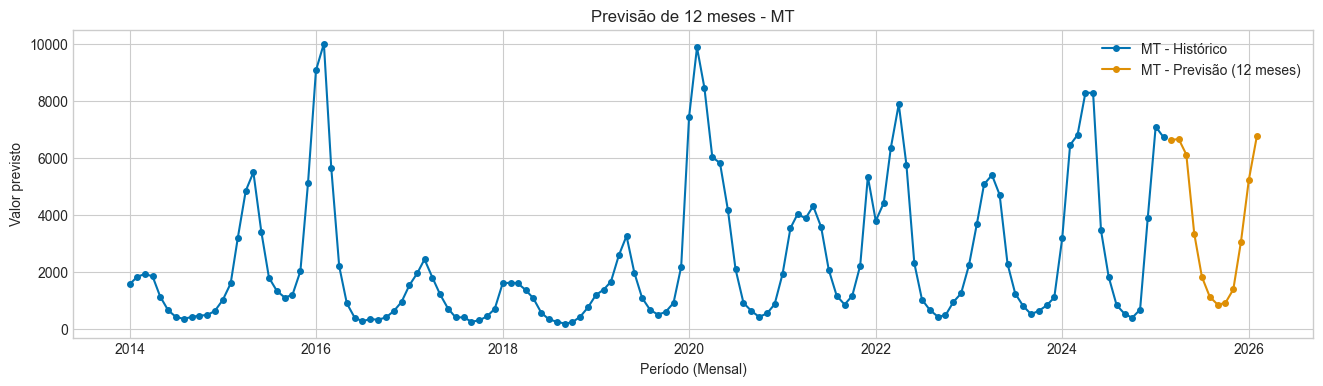

✅ Previsão e gráfico gerados para MT


<Figure size 1000x500 with 0 Axes>

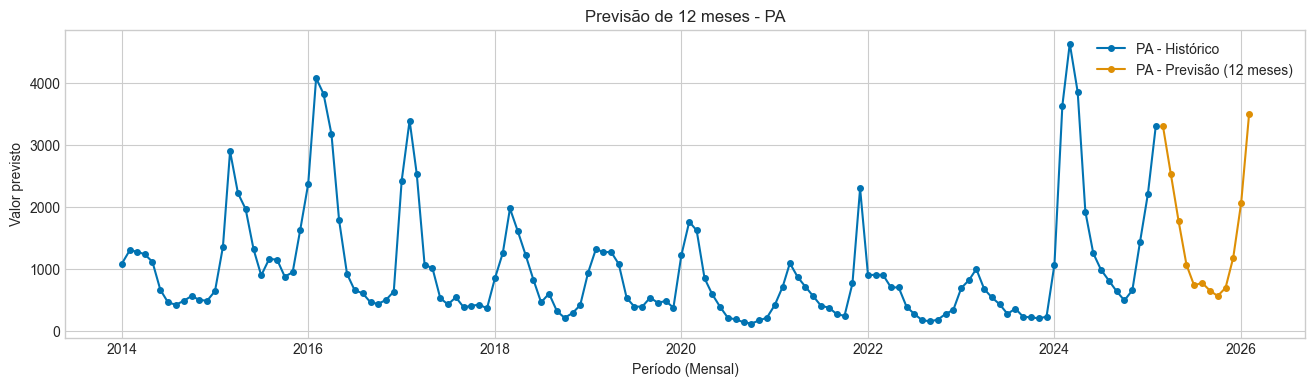

✅ Previsão e gráfico gerados para PA


<Figure size 1000x500 with 0 Axes>

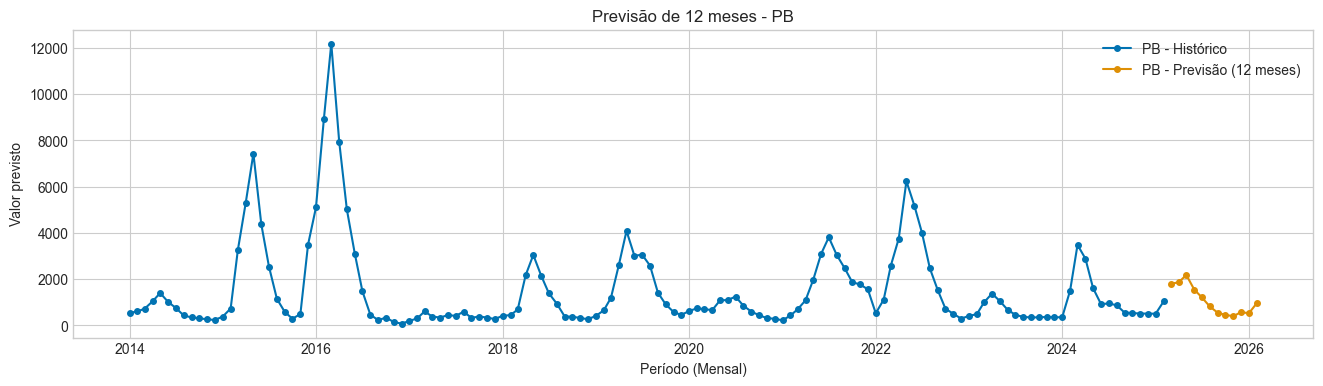

✅ Previsão e gráfico gerados para PB


<Figure size 1000x500 with 0 Axes>

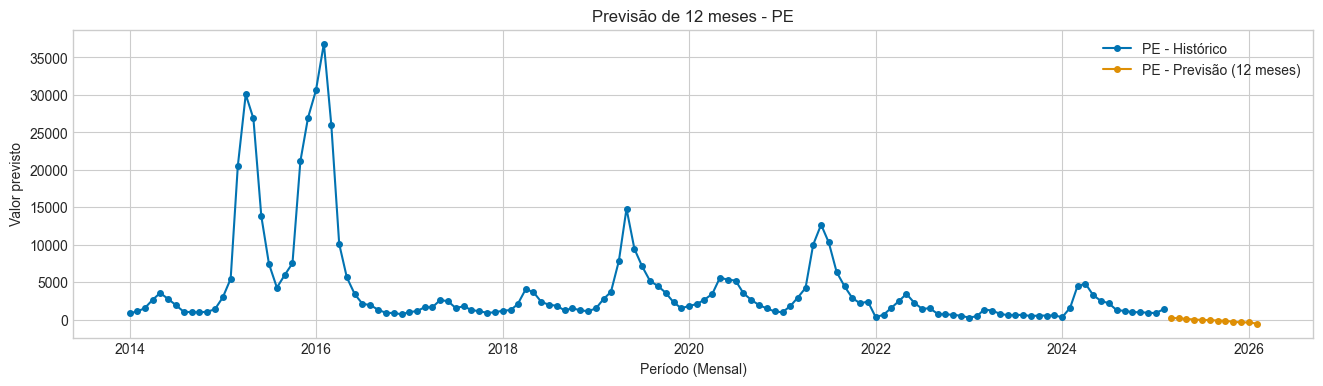

✅ Previsão e gráfico gerados para PE


<Figure size 1000x500 with 0 Axes>

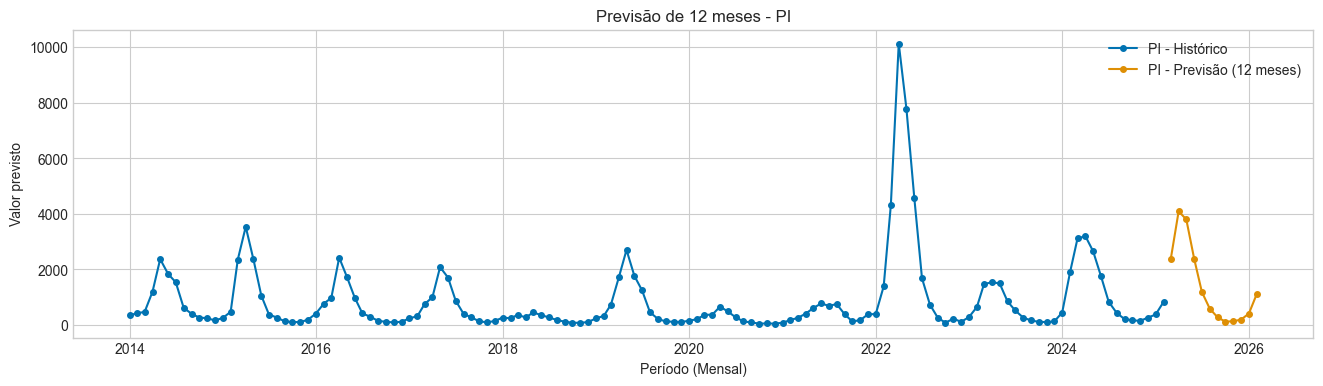

✅ Previsão e gráfico gerados para PI


<Figure size 1000x500 with 0 Axes>

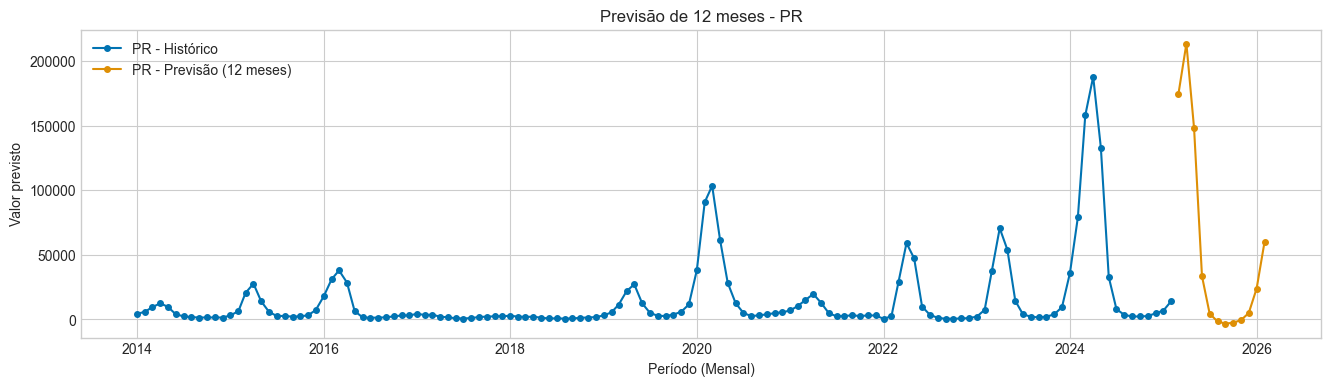

✅ Previsão e gráfico gerados para PR


<Figure size 1000x500 with 0 Axes>

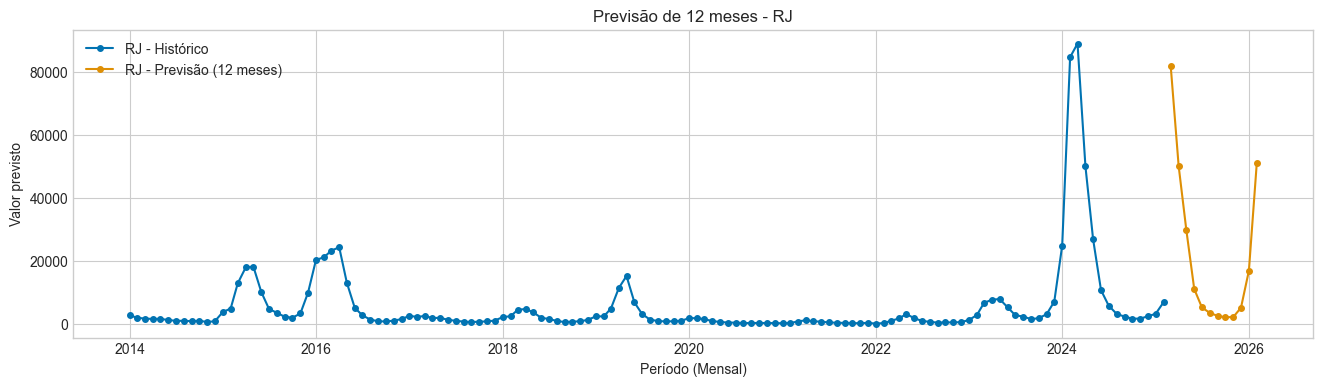

✅ Previsão e gráfico gerados para RJ


<Figure size 1000x500 with 0 Axes>

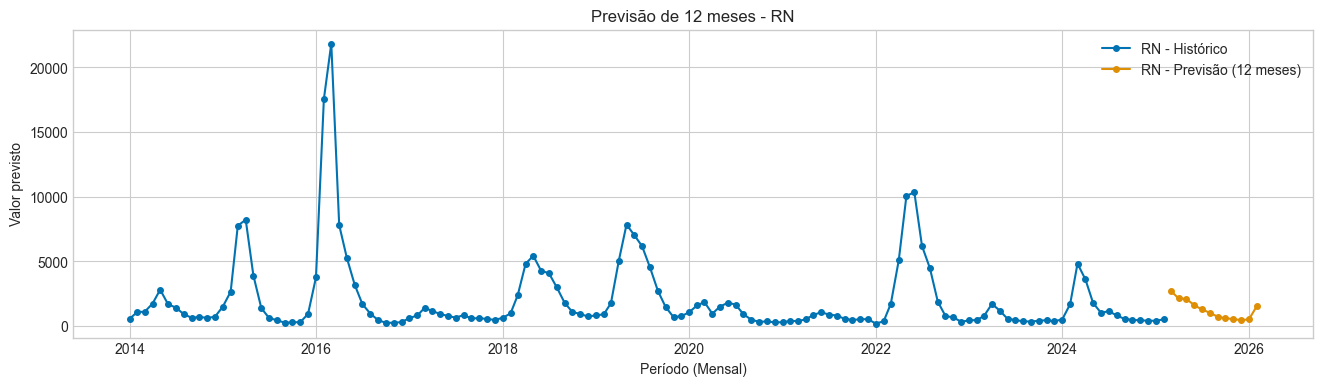

✅ Previsão e gráfico gerados para RN


<Figure size 1000x500 with 0 Axes>

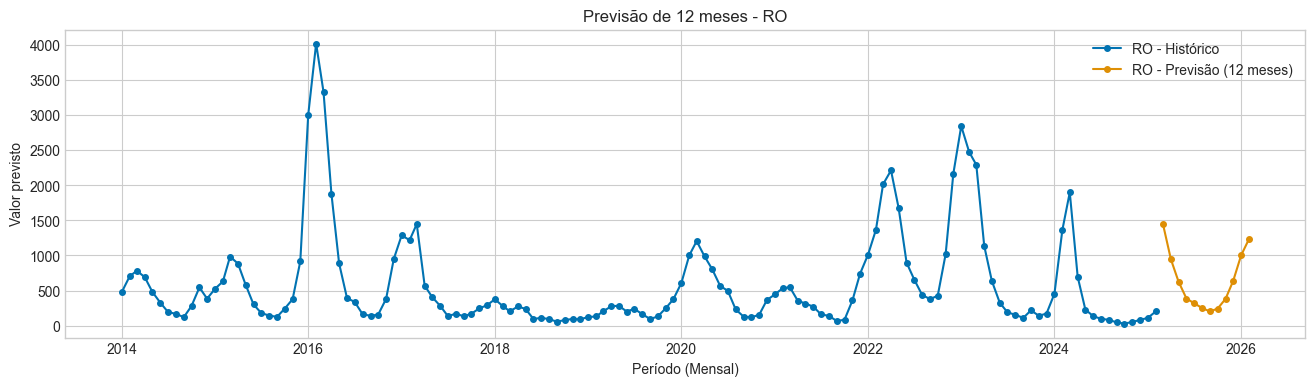

✅ Previsão e gráfico gerados para RO


<Figure size 1000x500 with 0 Axes>

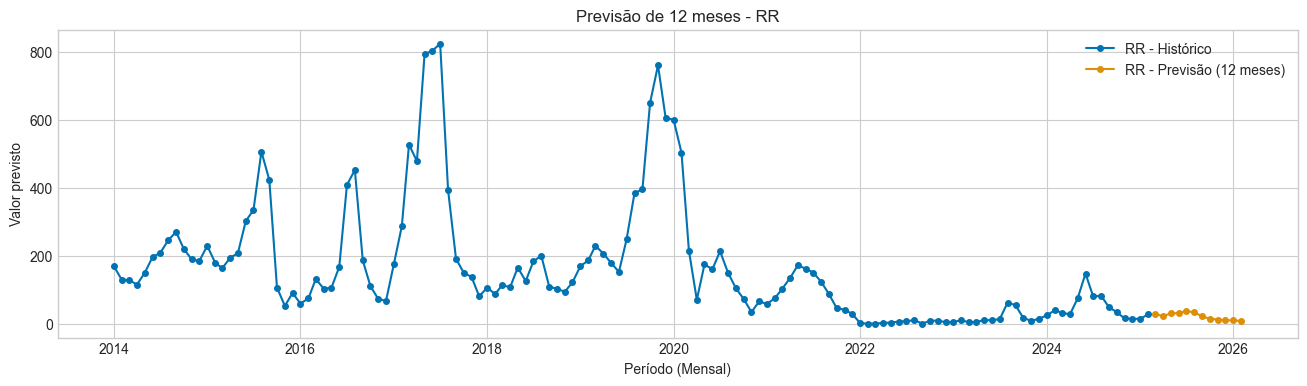

✅ Previsão e gráfico gerados para RR


<Figure size 1000x500 with 0 Axes>

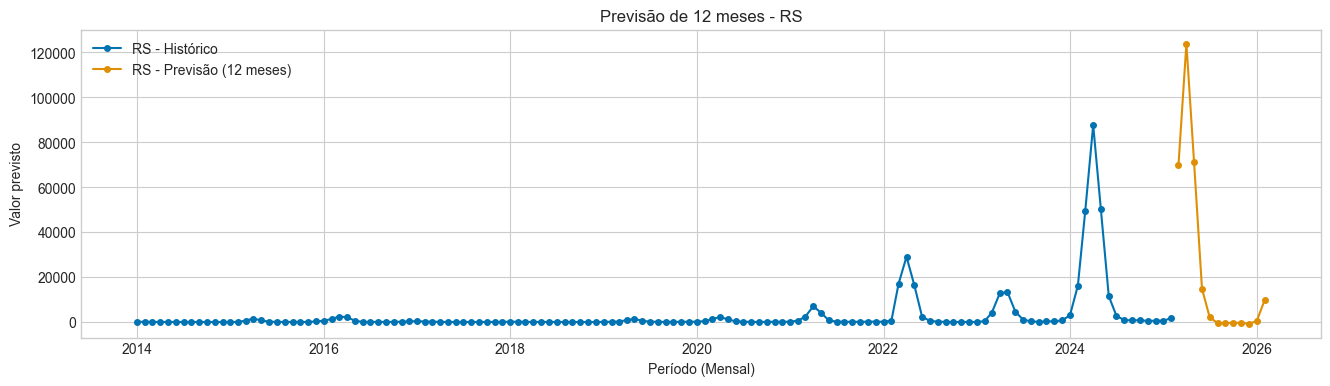

✅ Previsão e gráfico gerados para RS


<Figure size 1000x500 with 0 Axes>

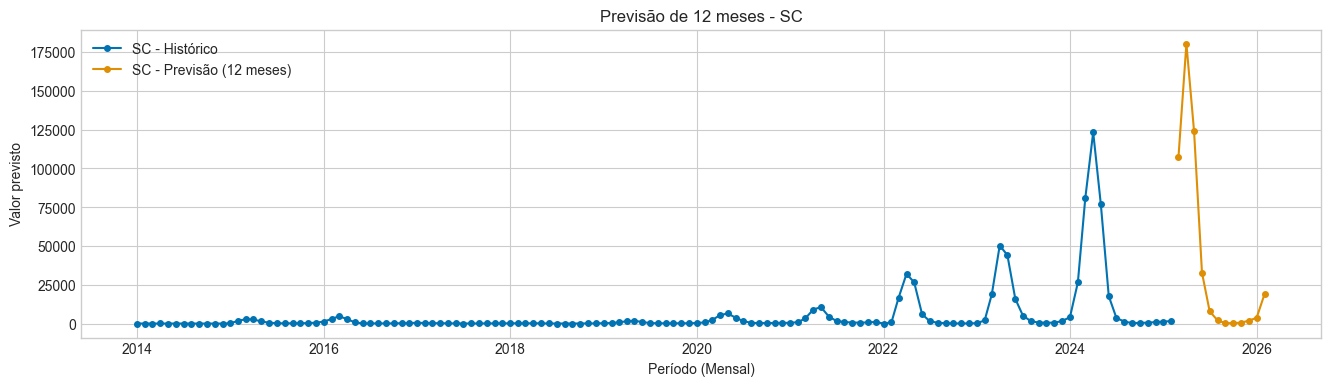

✅ Previsão e gráfico gerados para SC


<Figure size 1000x500 with 0 Axes>

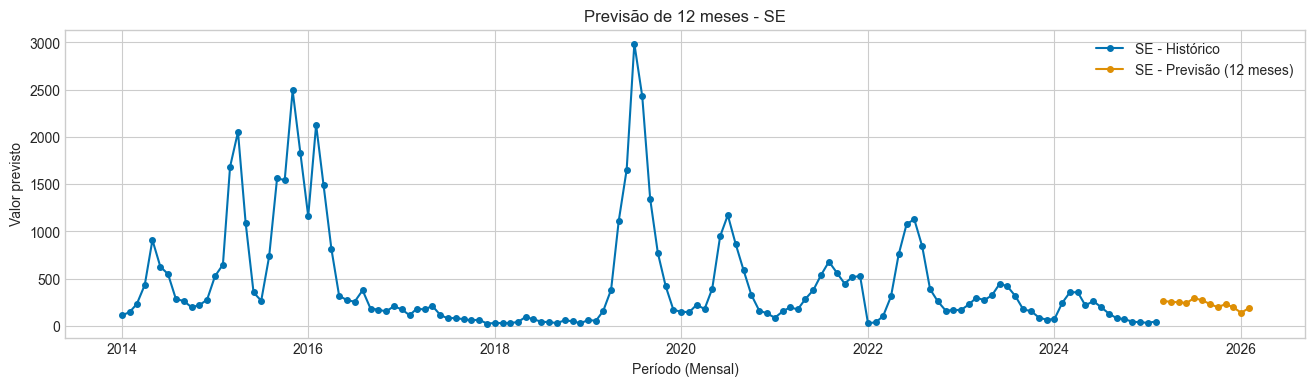

✅ Previsão e gráfico gerados para SE


<Figure size 1000x500 with 0 Axes>

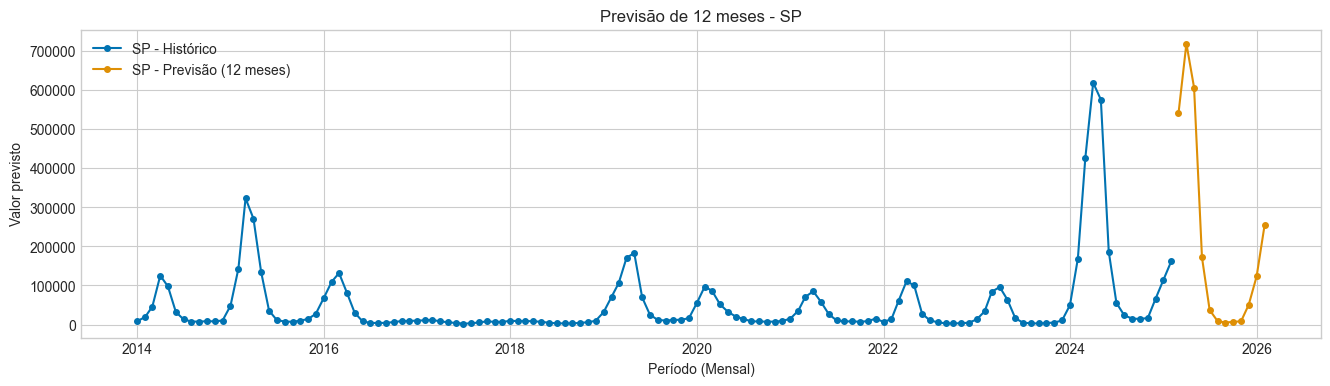

✅ Previsão e gráfico gerados para SP


<Figure size 1000x500 with 0 Axes>

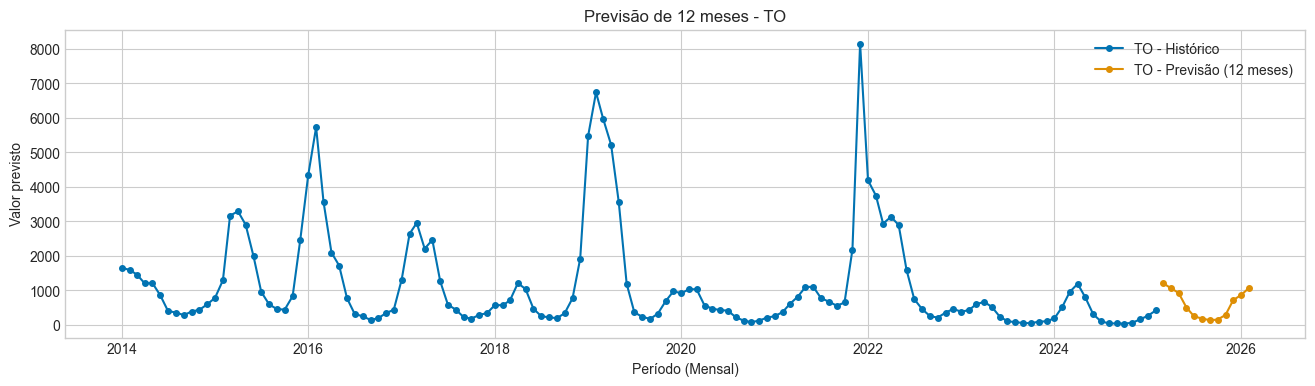

✅ Previsão e gráfico gerados para TO


In [147]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.utils.plotting import plot_series

# --- Caminho dos modelos ---
caminho_modelos = os.path.join('..', 'models', 'modelos_series_temporais')

# --- Horizonte de previsão (12 meses) ---
fh = np.arange(1, 13)

# Loop pelos estados e gerar previsões
for estado, serie in dfs_por_estado.items():
    caminho_modelo = os.path.join(caminho_modelos, f"modelo_prophet_{estado}.pkl")

    try:
        # --- Carregar modelo ---
        with open(caminho_modelo, 'rb') as f:
            modelo = pickle.load(f)

        # --- Gerar previsão ---
        y_pred = modelo.predict(fh=fh)

        # Garantir que o índice da previsão seja contínuo em relação ao histórico
        ultimo_periodo = serie.index.max()
        idx_futuro = pd.period_range(start=ultimo_periodo + 1, periods=len(fh), freq='M')

        # Converter y_pred em Series com PeriodIndex
        y_pred_series = pd.Series(y_pred.values, index=idx_futuro, name='Previsão')

        # --- Plotar série histórica + previsão ---
        plt.figure(figsize=(10, 5))
        plot_series(
            serie,
            y_pred_series,
            labels=[f"{estado} - Histórico", f"{estado} - Previsão (12 meses)"]
        )
        plt.title(f"Previsão de 12 meses - {estado}")
        plt.xlabel("Período (Mensal)")
        plt.ylabel("Valor previsto")
        plt.grid(True)
        plt.show()

        print(f"✅ Previsão e gráfico gerados para {estado}")

    except Exception as e:
        print(f"⚠️ Erro ao processar {estado}: {e}")
